In [8]:
import torch 
import numpy as np
from sklearn.base import BaseEstimator
from sklearn.ensemble import RandomForestRegressor

In [29]:
import torch
from typing import Tuple

def optimal_matching_l2_1d(a: torch.Tensor, b: torch.Tensor, squared: bool = True
                           ) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    """
    Optimal 1:1 matching between vectors a and b under L2 (or squared L2) in 1D.
    Works with shapes:
      - (n,), (n,1), (1,n)
      - batched (..., n) (batch dims must match between a and b)

    Args:
        a: Tensor with last dimension n
        b: Tensor with last dimension n
        squared: if True, cost is |a-b|^2; else |a-b|

    Returns:
        perm: LongTensor of shape (..., n), where b[..., perm[..., i]] is matched to a[..., i]
        b_opt: Tensor of shape (..., n), b permuted to align with a
        total_cost: Tensor of shape (...) (sum over last dim)
    """
    if a.shape[-1] != b.shape[-1]:
        raise ValueError("a and b must have the same number of elements along the last dimension.")

    # Align dtypes/devices for computation
    dtype = torch.promote_types(a.dtype, b.dtype) if a.dtype.is_floating_point or b.dtype.is_floating_point else torch.float32
    device = a.device if a.device == b.device else a.device

    a = a.to(device=device, dtype=dtype)
    b = b.to(device=device, dtype=dtype)

    # Canonicalize to (..., n)
    def _to_lastdim(x: torch.Tensor) -> torch.Tensor:
        if x.ndim == 1:
            return x.unsqueeze(0)  # (1, n)
        if x.shape[-1] == 1 and x.ndim >= 2:
            # (..., 1) -> squeeze, but keep at least 2D for consistent batching
            return x.squeeze(-1)
        if x.ndim >= 2 and x.shape[-2] == 1:
            # (..., 1, n) -> squeeze dim -2
            return x.squeeze(-2)
        return x

    a_ = _to_lastdim(a)
    b_ = _to_lastdim(b)

    # After canonicalization, ensure last dim matches and batch dims match
    if a_.shape != b_.shape:
        # allow broadcasting only on leading singleton batch dims
        if a_.shape[-1] != b_.shape[-1]:
            raise ValueError("Last dim mismatch after canonicalization.")
        # Try to broadcast (PyTorch will raise if impossible)
        a_, b_ = torch.broadcast_tensors(a_, b_)

    # Now we have (..., n)
    # Sort both along last dim and pair by rank (monotone coupling)
    ia = torch.argsort(a_, dim=-1)
    ib = torch.argsort(b_, dim=-1)

    # Build perm so that perm[..., ia[k]] = ib[k] for each position
    perm = torch.empty_like(ia)
    perm.scatter_(-1, ia, ib)

    # Permute b to align with a
    b_opt = torch.gather(b_, dim=-1, index=perm)

    diffs = a_ - b_opt
    pair_costs = diffs.pow(2) if squared else diffs.abs()
    total_cost = pair_costs.sum(dim=-1)

    # If original inputs were strictly 1D, return 1D outputs
    if a.ndim == 1 and b.ndim == 1:
        return perm.squeeze(0), b_opt.squeeze(0), total_cost.squeeze(0)

    return perm, b_opt, total_cost

In [111]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor

class DistLearner:
    def __init__(self,
                 model=None):
        if model is None:
            model = RandomForestRegressor(max_depth=None, n_estimators=500, random_state=0)
        self.model = model

    def fit(self, y: torch.Tensor, do_ot: bool = True):
        """
        Fits a RandomForest to a rank-aligned Gaussian covariate x0 and permuted y.
        y: torch.Tensor shape (n,), (n,1), or (1,n)
        do_ot: if True, perform optimal transport to align y to synthetic covariate
        """
        # Make y a clean 1D torch vector on CPU
        y_vec = y.detach().cpu().reshape(-1)

        n = y_vec.numel()
        # Synthetic 1D covariate to define the ordering
        x0 = torch.randn(n)  # 1D

        # Optimal monotone matching in 1D
        perm, y_opt, _ = optimal_matching_l2_1d(x0, y_vec, squared=True)

        # Fit sklearn model: X is (n,1), y is (n,)
        X_np = x0.numpy().reshape(-1, 1)
        y_np = y_opt.numpy()

        if do_ot:
            self.model.fit(X_np, y_np)
        else:
            self.model.fit(X_np, np.random.permutation(y_np))

    def sample(self, n: int) -> torch.Tensor:
        """
        Draws n new samples from the fitted model at random Gaussian covariates.
        Returns a 1D torch vector of length n (on CPU).
        """
        X_new = np.random.randn(n, 1)
        y_new = self.model.predict(X_new)  # shape (n,)
        return torch.from_numpy(y_new)

(array([0.01079036, 0.01618552, 0.08092769, 0.07013733, 0.14027466,
        0.23199241, 0.36687218, 0.26436378, 0.32910572, 0.25357326,
        0.18343609, 0.13487939, 0.06474215, 0.01618553, 0.02158071,
        0.00539518, 0.        , 0.00539518, 0.00539518, 0.00539518,
        0.        , 0.00539518, 0.02158071, 0.01079036, 0.04316141,
        0.09171799, 0.07013733, 0.08092764, 0.17264573, 0.11329876,
        0.20501654, 0.18883127, 0.21580717, 0.26436344, 0.19962163,
        0.26975896, 0.2319927 , 0.22659723, 0.19962163, 0.14566984,
        0.14566984, 0.07553241, 0.07013724, 0.05934705, 0.03237103,
        0.02158074, 0.01618552, 0.        , 0.        , 0.01079034]),
 array([-3.41682863, -3.23147798, -3.04612708, -2.86077642, -2.67542577,
        -2.49007511, -2.30472422, -2.11937356, -1.9340229 , -1.74867213,
        -1.56332135, -1.3779707 , -1.19261992, -1.00726926, -0.82191849,
        -0.63656777, -0.45121706, -0.26586634, -0.08051562,  0.10483511,
         0.29018584,  0.47

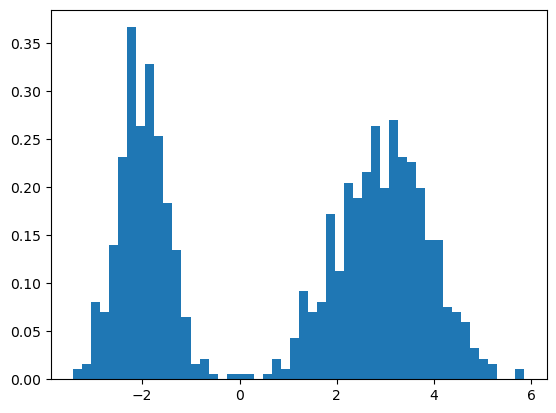

In [112]:
# sample y from a bimodal GMM
# --- simple 1D GMM sampler for ground truth ---
class GMM1D:
    def __init__(self, weights, means, stds, random_state: int = 123):
        self.weights = np.asarray(weights, dtype=np.float64)
        self.means = np.asarray(means, dtype=np.float64)
        self.stds = np.asarray(stds, dtype=np.float64)
        assert np.isclose(self.weights.sum(), 1.0), "weights must sum to 1."
        assert self.weights.shape == self.means.shape == self.stds.shape
        self.K = len(weights)
        self.rng = np.random.RandomState(random_state)

    def sample(self, n: int) -> torch.Tensor:
        comps = self.rng.choice(self.K, size=n, p=self.weights)
        z = self.rng.randn(n)
        x = self.means[comps] + self.stds[comps] * z
        return torch.from_numpy(x.astype(np.float32))
    

gmm = GMM1D(weights=[0.4, 0.6], means=[-2.0, 3.0], stds=[0.5, 1.0])
y = gmm.sample(1000)

# plot 
import matplotlib.pyplot as plt
plt.hist(y, bins=50, density=True)


/var/folders/ng/4_7_0hz56vnfj1yd8btkt5h80007z9/T/ipykernel_63034/4272429879.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(y)


(array([12.87878788,  3.48484848,  1.76767677,  1.71717172,  2.37373737,
         2.47474747,  1.41414141,  0.3030303 ,  0.        ,  0.        ,
         0.65656566,  2.17171717,  1.46464646,  2.02020202,  0.75757576,
         1.16161616,  0.80808081,  0.65656566,  0.15151515,  0.15151515,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
         1.01010101,  1.96969697,  3.13131313,  1.26262626,  1.36363636,
         0.75757576,  0.50505051,  0.4040404 ,  0.25252525,  0.1010101 ,
         0.        ,  0.05050505,  0.05050505,  0.4040404 ,  1.11111111,
         0.80808081,  0.15151515,  0.25252525,  0.35353535,  0.15151515]),
 array([0.    , 0.0198, 0.0396, 0.0594, 0.0792, 0.099 , 0.1188, 0.1386,
        0.1584, 0.1782, 0.198 , 0.2178, 0.2376, 0.2574, 0.2772, 0.297 ,
        0.3168, 0.3366, 0.3564, 0.3762, 0.396 , 0.4158, 0.4356, 0.4554,
        0.4752, 0.495 , 0.5148, 0.5346, 0.5544, 0.57

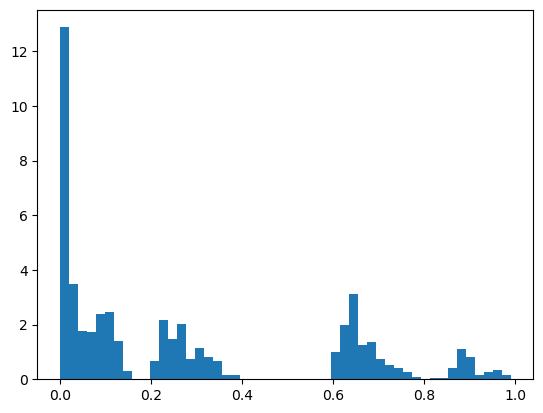

In [123]:
dist_learner = DistLearner()
y = torch.tensor(y)
dist_learner.fit(y, do_ot=False)

y_sampled = dist_learner.sample(1000)

plt.hist(y_sampled.numpy(), bins=50, density=True)

In [105]:
from ot import emd2_1d

N = 10_000
y_gt = gmm.sample(N)

y_sampled = dist_learner.sample(N)


dist = emd2_1d(y_gt.numpy(), y_sampled.numpy())
print(f"EMD between ground truth and sampled: {dist}")

EMD between ground truth and sampled: 0.02838685183000252


(array([37.3,  0. ,  0. ,  0. ,  0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,  0. ,
         0. ,  0. ,  0. ,  0. ,  0.1, 12.5]),
 array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14, 0.16, 0.18, 0.2 ,
        0.22, 0.24, 0.26, 0.28, 0.3 , 0.32, 0.34, 0.36, 0.38, 0.4 , 0.42,
        0.44, 0.46, 0.48, 0.5 , 0.52, 0.54, 0.56, 0.58, 0.6 , 0.62, 0.64,
        0.66, 0.68, 0.7 , 0.72, 0.74, 0.76, 0.78, 0.8 , 0.82, 0.84, 0.86,
        0.88, 0.9 , 0.92, 0.94, 0.96, 0.98, 1.  ]),
 <BarContainer object of 50 artists>)

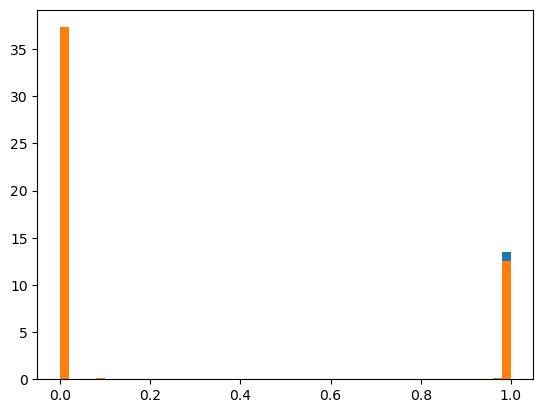

In [122]:
# discrete Bernoulli example
# discrete
y = torch.bernoulli(torch.ones(1000) * 0.3)
plt.hist(y.numpy(), bins=50, density=True)
dist_learner = DistLearner()
dist_learner.fit(y)

y_sampled = dist_learner.sample(1000)
plt.hist(y_sampled.numpy(), bins=50, density=True)


Mean(model vs gt) = 0.03568 ± 0.02693
Mean(gt vs gt)    = 0.03101 ± 0.03107


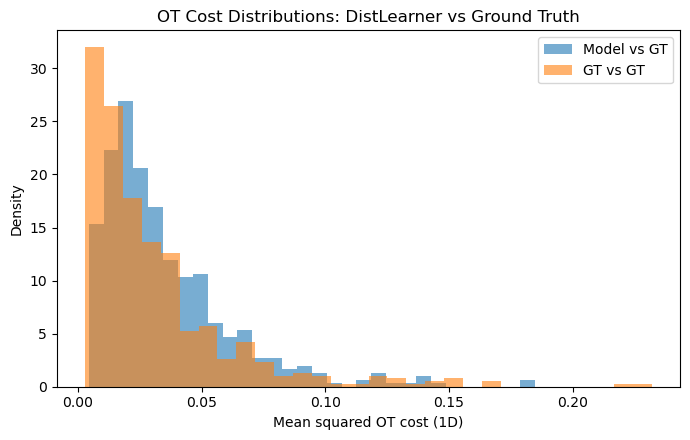

In [120]:
# --- add these imports if not already present ---
import numpy as np
import torch
import matplotlib.pyplot as plt

# --- helper: mean OT cost via your optimal_matching_l2_1d ---
def ot_cost_1d_mean(a: torch.Tensor, b: torch.Tensor, squared: bool = True) -> float:
    _, _, total_cost = optimal_matching_l2_1d(a.flatten(), b.flatten(), squared=squared)
    return (total_cost / a.numel()).item()



# --- evaluation routine ---
def run_eval_distlearner(
    k: int = 200,          # iterations
    n_train: int = 5000,   # training size for DistLearner
    n_eval: int = 500,     # per-iteration sample size
    squared: bool = True   # use squared L2 cost
):
    # 1) fix GT distribution (feel free to change params)
    gmm = GMM1D(
        weights=[0.35, 0.15, 0.50],
        means=[-2.0, 0.5, 2.5],
        stds=[0.6, 0.3, 1.0],
        random_state=123
    )

    # 2) train your DistLearner
    y_train = gmm.sample(n_train)
    dist_learner = DistLearner()
    dist_learner.fit(y_train)

    # 3) collect OT costs
    costs_model_vs_gt = []
    costs_gt_vs_gt = []

    for _ in range(k):
        y_gt = gmm.sample(n_eval)
        y_model = dist_learner.sample(n_eval).to(dtype=torch.float32)
        costs_model_vs_gt.append(ot_cost_1d_mean(y_gt, y_model, squared=squared))

    for _ in range(k):
        y1 = gmm.sample(n_eval)
        y2 = gmm.sample(n_eval)
        costs_gt_vs_gt.append(ot_cost_1d_mean(y1, y2, squared=squared))

    costs_model_vs_gt = np.array(costs_model_vs_gt)
    costs_gt_vs_gt = np.array(costs_gt_vs_gt)

    # 4) print summary
    print(f"Mean(model vs gt) = {costs_model_vs_gt.mean():.5f} ± {costs_model_vs_gt.std():.5f}")
    print(f"Mean(gt vs gt)    = {costs_gt_vs_gt.mean():.5f} ± {costs_gt_vs_gt.std():.5f}")

    # 5) plot both histograms
    plt.figure(figsize=(7, 4.5))
    plt.hist(costs_model_vs_gt, bins=30, density=True, alpha=0.6, label="Model vs GT")
    plt.hist(costs_gt_vs_gt, bins=30, density=True, alpha=0.6, label="GT vs GT")
    plt.xlabel("Mean squared OT cost (1D)")
    plt.ylabel("Density")
    plt.title("OT Cost Distributions: DistLearner vs Ground Truth")
    plt.legend()
    plt.tight_layout()
    plt.show()

# --- run it ---
if __name__ == "__main__":
    run_eval_distlearner(k=500, n_train=1000, n_eval=1000)